# Exploratory Data Analysis: Fake News Dataset

## 1. Set up (Load Library)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data

In [5]:
df = pd.read_csv("Dataset/fake_news_dataset.csv")
df.head()

,title,text,date,source,author,category,label
0,Foreign Democrat final.,more tax development both store agreement lawy...,2023-03-10,NY Times,Paula George,Politics,real
1,To offer down resource great point.,probably guess western behind likely next inve...,2022-05-25,Fox News,Joseph Hill,Politics,fake
2,Himself church myself carry.,them identify forward present success risk sev...,2022-09-01,CNN,Julia Robinson,Business,fake
3,You unit its should.,phone which item yard Republican safe where po...,2023-02-07,Reuters,Mr. David Foster DDS,Science,fake
4,Billion believe employee summer how.,wonder myself fact difficult course forget exa...,2023-04-03,CNN,Austin Walker,Technology,fake


## 3. Structural Overview

In [6]:
print("Shape:", df.shape)
df.info()

Shape: (20000, 7)
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   title     20000 non-null  str  
 1   text      20000 non-null  str  
 2   date      20000 non-null  str  
 3   source    19000 non-null  str  
 4   author    19000 non-null  str  
 5   category  20000 non-null  str  
 6   label     20000 non-null  str  
dtypes: str(7)
memory usage: 1.1 MB


## 4. Data Quality Checks

### Missing Values

In [8]:
df.isnull().sum().to_frame("missing_count")

,missing_count
title,0
text,0
date,0
source,1000
author,1000
category,0
label,0


columns `source` and `author` both have missing values.

In [9]:
(df.isnull().sum() / len(df) * 100).round(2).to_frame("missing_%")

,missing_%
title,0.0
text,0.0
date,0.0
source,5.0
author,5.0
category,0.0
label,0.0


### Duplicates

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### Date Range & Parsing

In [11]:
df["date"] = pd.to_datetime(df["date"])
print("Date range:", df["date"].min(), "to", df["date"].max())

Date range: 2022-04-26 00:00:00 to 2025-04-25 00:00:00


## 5. Target Variable: `label`

understand how many real and fake new contain in this dataset

In [12]:
df["label"].value_counts(normalize=True).mul(100).round(1)

label
fake    50.3
real    49.7
Name: proportion, dtype: float64

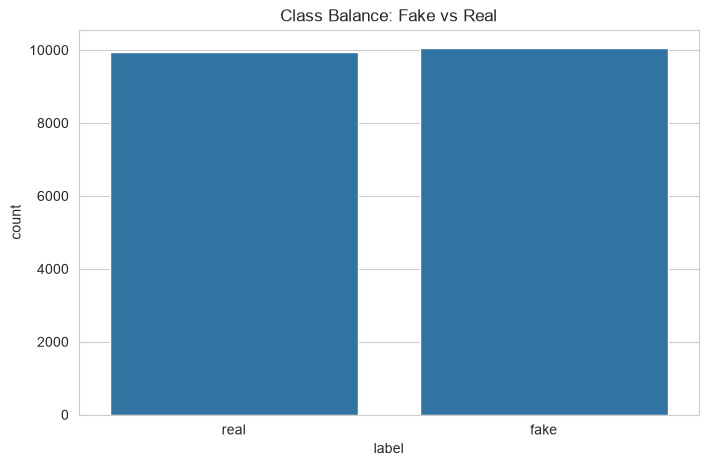

In [13]:
sns.countplot(data=df, x="label")
plt.title("Class Balance: Fake vs Real")
plt.show()

## 6. Univariate Analysis (Categorical Metadata)

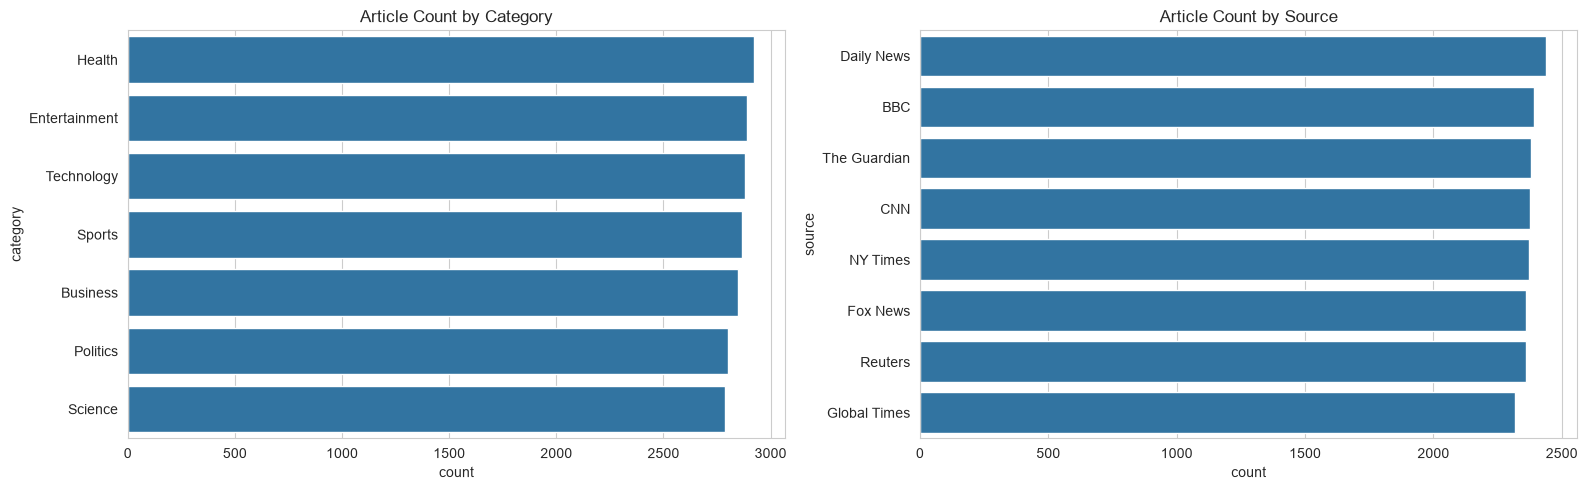

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df, y="category", order=df["category"].value_counts().index, ax=axes[0])
axes[0].set_title("Article Count by Category")

sns.countplot(data=df, y="source", order=df["source"].value_counts().index, ax=axes[1])
axes[1].set_title("Article Count by Source")
plt.tight_layout()
plt.show()

## 7. Univariate Analysis (Text Length)

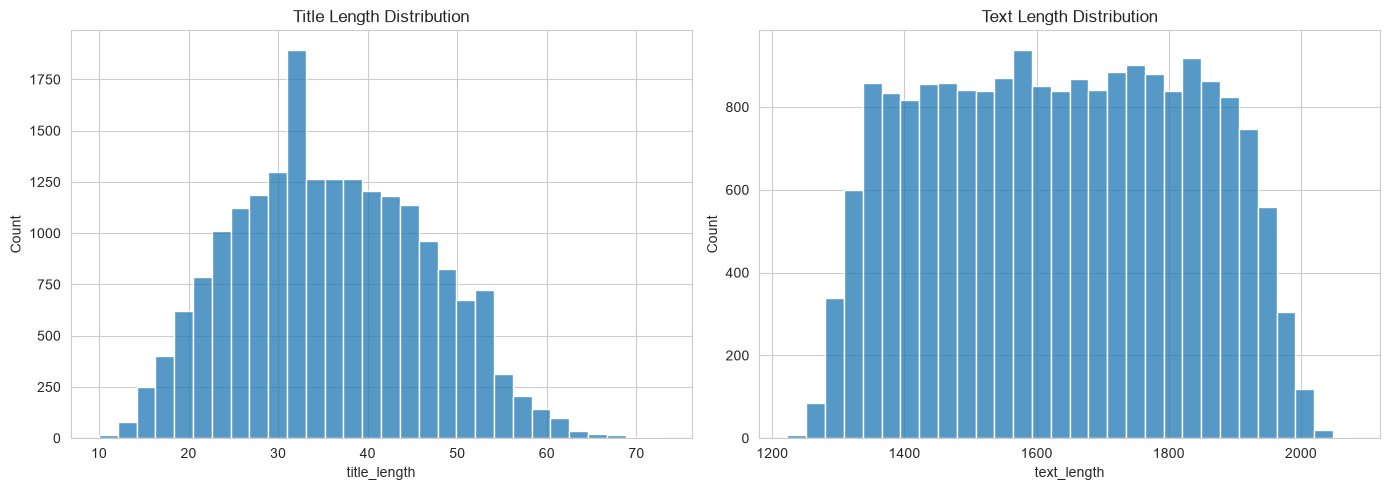

In [15]:
df["title_length"] = df["title"].str.len()
df["text_length"] = df["text"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["title_length"], bins=30, ax=axes[0])
axes[0].set_title("Title Length Distribution")

sns.histplot(df["text_length"], bins=30, ax=axes[1])
axes[1].set_title("Text Length Distribution")
plt.tight_layout()
plt.show()

In [22]:
print("Overall average text length (characters):", round(df["text_char_length"].mean(), 1))
print("Overall average text length (words):", round(df["text_word_count"].mean(), 1))
print()

print("Average text length by category:")
display(df.groupby("category")[["text_char_length", "text_word_count"]].mean().round(1).sort_values("text_word_count", ascending=False))
print()

print("Average text length by source:")
display(df.groupby("source")[["text_char_length", "text_word_count"]].mean().round(1).sort_values("text_word_count", ascending=False))
print()

print("Average text length by author (top 10 by article count):")
top_authors = df["author"].value_counts().head(10).index
display(df[df["author"].isin(top_authors)].groupby("author")[["text_char_length", "text_word_count"]].mean().round(1).sort_values("text_word_count", ascending=False))

Overall average text length (characters): 1635.1
Overall average text length (words): 250.2

Average text length by category:


,text_char_length,text_word_count
category,,
Science,1643.2,251.2
Technology,1637.5,250.6
Sports,1634.7,250.2
Business,1635.8,250.1
Entertainment,1632.5,249.9
Politics,1631.0,249.7
Health,1631.4,249.6



Average text length by source:


,text_char_length,text_word_count
source,,
Global Times,1639.9,250.9
CNN,1637.9,250.6
Daily News,1638.2,250.6
The Guardian,1636.9,250.5
Reuters,1635.6,250.2
Fox News,1634.8,250.1
NY Times,1633.3,250.1
BBC,1627.2,249.0



Average text length by author (top 10 by article count):


,text_char_length,text_word_count
author,,
Michael Smith,1748.3,266.6
Lisa Williams,1675.4,256.7
David Brown,1680.9,255.9
Michael Lee,1669.4,253.7
John Smith,1614.8,248.5
Jennifer Davis,1571.9,238.9
James Smith,1557.4,238.9
Christopher Johnson,1564.9,238.2
John Brown,1520.6,231.6


## 8. Bivariate Analysis (Metadata vs. Label)

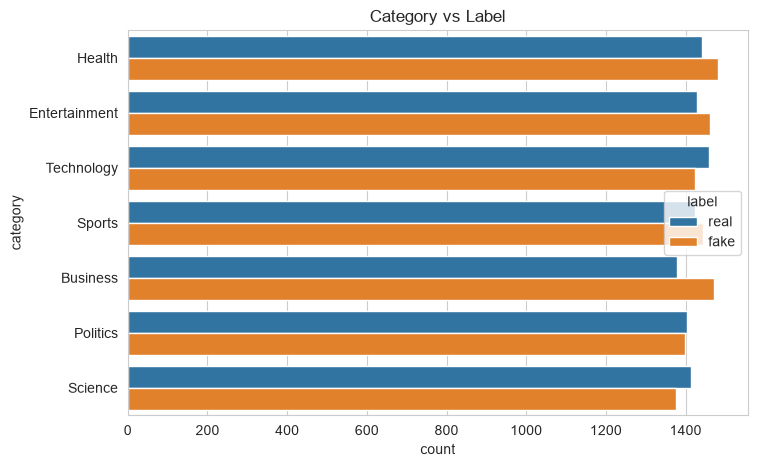

In [16]:
sns.countplot(data=df, y="category", hue="label", order=df["category"].value_counts().index)
plt.title("Category vs Label")
plt.show()

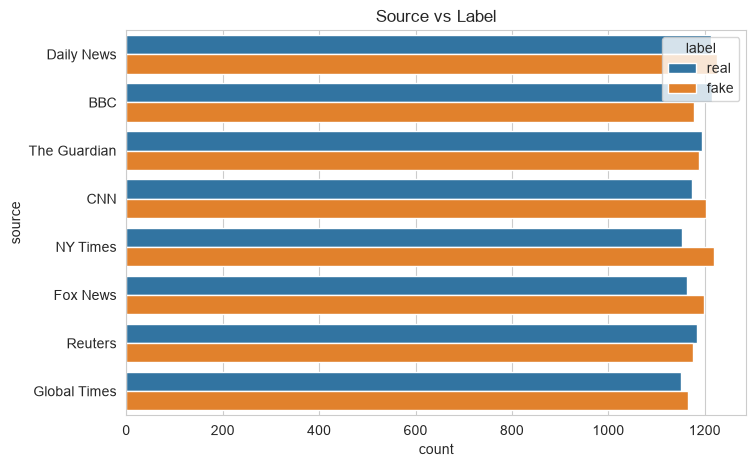

In [17]:
sns.countplot(data=df, y="source", hue="label", order=df["source"].value_counts().index)
plt.title("Source vs Label")
plt.show()

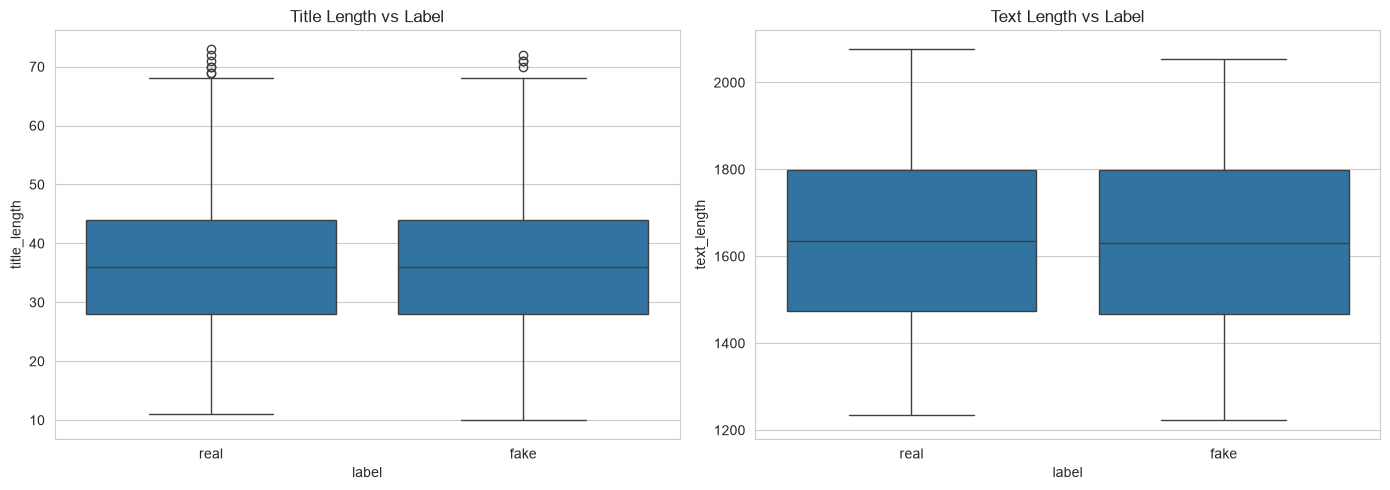

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="label", y="title_length", ax=axes[0])
axes[0].set_title("Title Length vs Label")

sns.boxplot(data=df, x="label", y="text_length", ax=axes[1])
axes[1].set_title("Text Length vs Label")
plt.tight_layout()
plt.show()

## 9. Time-Based Analysis

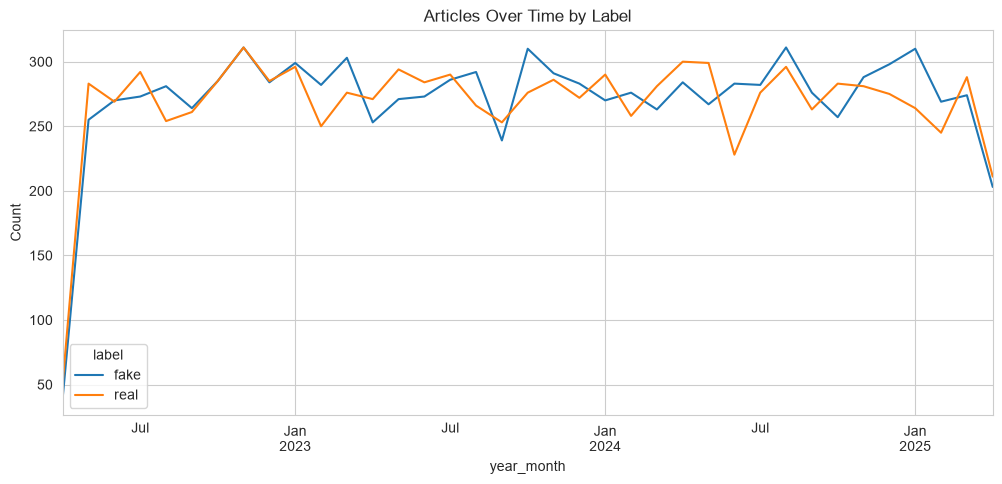

In [19]:
df["year_month"] = df["date"].dt.to_period("M")
monthly = df.groupby(["year_month", "label"]).size().unstack()

monthly.plot(kind="line", figsize=(12, 5))
plt.title("Articles Over Time by Label")
plt.ylabel("Count")
plt.show()

## 10. Author Analysis

In [20]:
print("Unique authors:", df["author"].nunique())
df["author"].value_counts().head(10)

Unique authors: 17051


author
Michael Smith          12
John Smith             11
Christopher Johnson     9
David Brown             7
John Brown              7
James Smith             7
Lisa Williams           7
Michael Lee             7
Jennifer Davis          7
David Johnson           6
Name: count, dtype: int64